Loaded samples: (12000, 69)
Classes: {'post-feeding', 'pre-feeding', 'feeding', 'background'}
Epoch 0: Loss = 46.1865
Epoch 1: Loss = 6.5194
Epoch 2: Loss = 3.8687
Epoch 3: Loss = 9.8649
Epoch 4: Loss = 3.0500
Epoch 5: Loss = 2.0706
Epoch 6: Loss = 1.1442
Epoch 7: Loss = 1.1423
Epoch 8: Loss = 1.1543
Epoch 9: Loss = 2.3981
Epoch 10: Loss = 0.5287
Epoch 11: Loss = 0.3450
Epoch 12: Loss = 2.0939
Epoch 13: Loss = 5.3707
Epoch 14: Loss = 11.5587
Epoch 15: Loss = 2.4839
Epoch 16: Loss = 1.5636
Epoch 17: Loss = 0.8202
Epoch 18: Loss = 0.2553
Epoch 19: Loss = 0.5403

--- FINAL INTERACTION MODEL RESULTS ---
Training time: 26.7057 s
Inference time per sample (ms): 0.0433
Accuracy: 0.9983
Precision: 0.9993
Recall: 0.9933
F1-score: 0.9963
ROC-AUC: 1.0

Confusion Matrix:
 [[ 180    0    0    0]
 [   0  146    0    4]
 [   0    0  630    0]
 [   0    0    0 1440]]


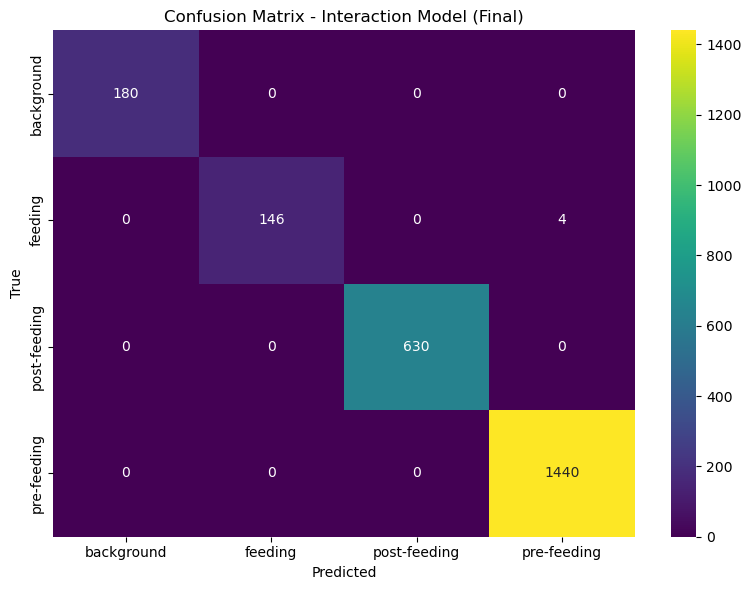

In [5]:
import os
import time
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split


# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
DATASET_PATH = "/home/feliciano/Documents/DATASET_SEABREAM_SEGMENTED/Segmented_2s"
SAMPLE_RATE = 8000
N_MELS = 64
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# ---------------------------------------------------------
# FEATURE EXTRACTION (FIXED ✅)
# ---------------------------------------------------------
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)

    # Mel spectrogram
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, fmax=1000
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # ✅ FIXED spectral contrast (safe for 8kHz)
    contrast = librosa.feature.spectral_contrast(
        y=y,
        sr=sr,
        fmin=50,
        n_bands=4
    )

    # ✅ Global pooling (dimension reduction)
    mel_feat = np.mean(mel_db, axis=1)
    contrast_feat = np.mean(contrast, axis=1)

    return np.concatenate([mel_feat, contrast_feat])


# ---------------------------------------------------------
# LABEL MAPPING
# ---------------------------------------------------------
def map_label_from_path(path):
    p = path.lower()

    if "background" in p:
        return "background"
    if "pre" in p and "feed" in p:
        return "pre-feeding"
    if "post" in p and "feed" in p:
        return "post-feeding"
    if "feeding" in p:
        return "feeding"

    return None


# ---------------------------------------------------------
# LOAD DATASET
# ---------------------------------------------------------
X, y = [], []

for root, _, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(".wav"):
            path = os.path.join(root, file)
            label = map_label_from_path(root)

            if label is None:
                continue

            X.append(extract_features(path))
            y.append(label)

X = np.array(X)
y = np.array(y)

print("Loaded samples:", X.shape)
print("Classes:", set(y))


# ---------------------------------------------------------
# PREPROCESS
# ---------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(y)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
X_test = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_train = torch.tensor(y_train).to(DEVICE)
y_test = torch.tensor(y_test).to(DEVICE)

input_dim = X_train.shape[1]
num_classes = len(np.unique(y))


# ---------------------------------------------------------
# YOUR OPTIMISED INTERACTION MODEL ✅
# ---------------------------------------------------------
class InteractionModel(nn.Module):
    def __init__(self, dim, num_classes, k=32):
        super().__init__()

        # Low-rank projections (memory-safe)
        self.query = nn.Linear(dim, k)
        self.key = nn.Linear(dim, k)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # Projection
        Q = self.query(x)
        K = self.key(x)

        # Attention (your A_ij ✅)
        scores = Q @ K.T / np.sqrt(Q.shape[1])
        A = torch.softmax(scores, dim=1)

        # Interaction
        y = A @ x

        # Residual connection ✅
        y = y + x

        return self.classifier(y)


# ---------------------------------------------------------
# TRAINING
# ---------------------------------------------------------
model = InteractionModel(input_dim, num_classes).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

start_time = time.time()

epochs = 20
batch_size = 32

for epoch in range(epochs):
    model.train()

    perm = torch.randperm(X_train.size(0))
    total_loss = 0

    for i in range(0, X_train.size(0), batch_size):
        idx = perm[i:i+batch_size]
        xb = X_train[idx]
        yb = y_train[idx]

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}: Loss = {total_loss:.4f}")

train_time = time.time() - start_time


# ---------------------------------------------------------
# INFERENCE
# ---------------------------------------------------------
model.eval()
start_inf = time.time()

with torch.no_grad():
    outputs = model(X_test)
    probs = torch.softmax(outputs, dim=1)
    y_pred = torch.argmax(probs, dim=1).cpu().numpy()
    y_prob = probs.cpu().numpy()

inf_time = (time.time() - start_inf) / len(X_test)


# ---------------------------------------------------------
# METRICS
# ---------------------------------------------------------
y_true = y_test.cpu().numpy()

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="macro")
rec = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")

try:
    auc = roc_auc_score(y_true, y_prob, multi_class="ovr")
except:
    auc = None

cm = confusion_matrix(y_true, y_pred)


# ---------------------------------------------------------
# RESULTS
# ---------------------------------------------------------
print("\n--- FINAL INTERACTION MODEL RESULTS ---")
print("Training time:", round(train_time, 4), "s")
print("Inference time per sample (ms):", round(inf_time * 1000, 4))
print("Accuracy:", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall:", round(rec, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", auc)
print("\nConfusion Matrix:\n", cm)


# ---------------------------------------------------------
# CONFUSION MATRIX PLOT
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix - Interaction Model (Final)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()